# Rider Acceptance Prediction — Phần 2: Model cải thiện như thế nào khi FE? (bản có SHAP)

| | | | |
|---|---|---|---|
| **Dự án** | Rider Acceptance (Matching & Dispatch) | **Phần** | 2/N — So sánh FAIR: hiệu quả của FE, tách riêng theo architecture |
| **Mục tiêu** | Metrics tăng/giảm ra sao khi CHỈ thêm 6 feature mới, GIỮ NGUYÊN architecture — đo riêng cho từng architecture để không lẫn 2 hiệu ứng | **Test set** | 13/07/2026, n=8.609 đơn post-dispatch (n=9.347 nếu tính cả pre-dispatch) |
| **4 model so sánh** | **14ft** (model-only, gốc) · **20ft** (model-only + 6 feature FE) · **13ft** (rule+model, gốc) · **19ft** (rule+model + 6 feature FE = Baseline hiện tại) | |

---

## 0. Vì sao cần tách so sánh theo architecture — bài học từ bản báo cáo trước

Bản báo cáo Phần 2 trước so sánh thẳng **Baseline v0 (14ft, model-only)** với **Baseline hiện tại (19ft, rule+model)** — nhưng đây là so sánh **KHÔNG fair**, vì 2 model khác nhau ở **2 chỗ CÙNG LÚC**:

1. **Architecture**: v0 gộp pre+post vào 1 model (`is_post_dispatch` là feature) → hiện tại tách `is_post_dispatch` thành rule if/else bên ngoài (xem Phần 1).
2. **Feature engineering**: 14 → 19 feature (6 feature mới từ FE).

So sánh 14ft-model-only thẳng với 19ft-rule+model **không tách được** cải thiện đến từ đâu — có thể do FE, có thể do đổi architecture, hoặc cả 2. Để so sánh **fair (apples-to-apples)**, báo cáo này thay bằng **2 cặp so sánh riêng**, mỗi cặp CHỈ đổi đúng 1 biến (feature count), GIỮ NGUYÊN architecture:

| Cặp so sánh | Architecture | Model gốc | Model +FE | Biến duy nhất thay đổi |
|---|---|---|---|---|
| **#1 — Model-only** | `is_post_dispatch` NẰM TRONG model, train combined pre+post | 14ft | 20ft (14+6) | chỉ feature count |
| **#2 — Rule + Model** | `is_post_dispatch` LÀ RULE bên ngoài, model chỉ train/infer post-dispatch | 13ft | 19ft (13+6) = Baseline hiện tại | chỉ feature count |

Hiệu ứng của riêng **architecture** (không liên quan FE) đã được đo tách riêng ở Phần 1 (13ft vs 14ft, cả 2 đều KHÔNG có FE — chênh ±0,002, không đáng kể).

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt
from IPython.display import display

import features as F
from train import PARAMS, RAW, TEST_DATE, ART
from evaluation import evaluate

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

In [2]:
orders, customer_daily = F.load_raw(RAW)
df, X, y = F.build_features(orders, customer_daily, verbose=False)
is_test = df.order_date >= pd.Timestamp(TEST_DATE)
post_mask = df.is_post_dispatch.astype(int) == 1

NEW_6 = ['pickup_distance_km', 'payment_method', 'dist_center_km',
         'cust_completion_rate_30d', 'dist_airport_km', 'dist_hotspot_km']

print(f'Tổng {len(df):,} đơn · post-dispatch {post_mask.mean():.1%} · test {is_test.sum():,} đơn (post: {(is_test & post_mask).sum():,})')
print(f'6 feature mới từ FE: {NEW_6}')

Tổng 280,110 đơn · post-dispatch 90.9% · test 9,347 đơn (post: 8,609)
6 feature mới từ FE: ['pickup_distance_km', 'payment_method', 'dist_center_km', 'cust_completion_rate_30d', 'dist_airport_km', 'dist_hotspot_km']


## 1. Train 4 model — 2 architecture × (có FE / không FE)

### 1.1 · Model-only architecture — 14ft (gốc) và 20ft (+FE)

In [3]:
ORIG_14 = ['total_fee', 'trip_distance_km', 'fee_per_km', 'surge_multiplier', 'hour_of_day',
           'is_weekend', 'is_schedule_order', 'cust_cancel_rate_30d', 'cust_orders_30d',
           'travel_mode', 'vertical_name', 'is_post_dispatch', 'eta_seconds', 're_dispatch_counts']
CAT_14 = ['travel_mode', 'vertical_name']
FEATURES_20 = ORIG_14 + NEW_6
CAT_20 = CAT_14 + ['payment_method']

# --- 14ft (model-only, gốc) ---
X14 = df[ORIG_14].copy()
for c in CAT_14:
    X14[c] = X14[c].astype('category')
X14_tr, y14_tr = X14[~is_test], y[~is_test]
X14_te, y14_te = X14[is_test].copy(), y[is_test]
for c in CAT_14:
    X14_te[c] = pd.Categorical(X14_te[c], categories=X14_tr[c].cat.categories)

model14 = lgb.train(PARAMS, lgb.Dataset(X14_tr, y14_tr), num_boost_round=500,
                     valid_sets=[lgb.Dataset(X14_te, y14_te)], valid_names=['test'],
                     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
print(f'14ft (model-only, gốc)  — dừng ở vòng {model14.best_iteration}, train n={len(X14_tr):,}')

# --- 20ft (model-only + 6 feature FE) — CÙNG architecture (combined pre+post) với 14ft, chỉ thêm feature ---
X20 = df[FEATURES_20].copy()
for c in CAT_20:
    X20[c] = X20[c].astype('category')
X20_tr, y20_tr = X20[~is_test], y[~is_test]
X20_te, y20_te = X20[is_test].copy(), y[is_test]
for c in CAT_20:
    X20_te[c] = pd.Categorical(X20_te[c], categories=X20_tr[c].cat.categories)

model20 = lgb.train(PARAMS, lgb.Dataset(X20_tr, y20_tr), num_boost_round=500,
                     valid_sets=[lgb.Dataset(X20_te, y20_te)], valid_names=['test'],
                     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
print(f'20ft (model-only + FE)  — dừng ở vòng {model20.best_iteration}, train n={len(X20_tr):,}')

14ft (model-only, gốc)  — dừng ở vòng 224, train n=270,763


20ft (model-only + FE)  — dừng ở vòng 254, train n=270,763


### 1.2 · Rule + Model architecture — 13ft (gốc) và 19ft (+FE = Baseline hiện tại)

In [4]:
ORIG_13 = ['total_fee', 'trip_distance_km', 'fee_per_km', 'surge_multiplier', 'hour_of_day',
           'is_weekend', 'is_schedule_order', 'cust_cancel_rate_30d', 'cust_orders_30d',
           'travel_mode', 'vertical_name', 'eta_seconds', 're_dispatch_counts']
CAT_13 = ['travel_mode', 'vertical_name']

# --- 13ft (rule + model, gốc) — is_post_dispatch KHÔNG trong model, chỉ train/test trên post-dispatch ---
X13 = df[ORIG_13].copy()
for c in CAT_13:
    X13[c] = X13[c].astype('category')
X13_tr, y13_tr = X13[~is_test & post_mask], y[~is_test & post_mask]
X13_te, y13_te = X13[is_test & post_mask].copy(), y[is_test & post_mask]
for c in CAT_13:
    X13_te[c] = pd.Categorical(X13_te[c], categories=X13_tr[c].cat.categories)

model13 = lgb.train(PARAMS, lgb.Dataset(X13_tr, y13_tr), num_boost_round=500,
                     valid_sets=[lgb.Dataset(X13_te, y13_te)], valid_names=['test'],
                     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
print(f'13ft (rule+model, gốc)  — dừng ở vòng {model13.best_iteration}, train n={len(X13_tr):,}')

# --- 19ft (rule + model + 6 feature FE) = Baseline hiện tại (đúng train.py production) ---
X19_tr, y19_tr = X[~is_test & post_mask], y[~is_test & post_mask]
X19_te, y19_te = X[is_test & post_mask].copy(), y[is_test & post_mask]
for c in F.CATEGORICAL_FEATURES:
    X19_te[c] = pd.Categorical(X19_te[c], categories=X19_tr[c].cat.categories)

model19 = lgb.train(PARAMS, lgb.Dataset(X19_tr, y19_tr), num_boost_round=500,
                     valid_sets=[lgb.Dataset(X19_te, y19_te)], valid_names=['test'],
                     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
print(f'19ft (rule+model + FE)  — dừng ở vòng {model19.best_iteration}, train n={len(X19_tr):,} (= Baseline hiện tại)')

13ft (rule+model, gốc)  — dừng ở vòng 238, train n=245,982


19ft (rule+model + FE)  — dừng ở vòng 312, train n=245,982 (= Baseline hiện tại)


## 2. So sánh FAIR #1 — Model-only: 14ft (gốc) vs 20ft (+FE)

Cả 2 model CÙNG architecture (combined pre+post, `is_post_dispatch` là feature) — biến duy nhất thay đổi là **có/không 6 feature FE**. 2 cách đo:
- **Post-dispatch**: lọc cả 2 theo `is_post_dispatch=True` — đo đúng khả năng trên phần dữ liệu khó.
- **Toàn bộ test** (combined, tự nhiên — model-only tự quyết định cho cả pre lẫn post, không cần rule ngoài).

In [5]:
p14_te = model14.predict(X14_te, num_iteration=model14.best_iteration)
p20_te = model20.predict(X20_te, num_iteration=model20.best_iteration)
post_te_on_full_test = df[is_test].is_post_dispatch.astype(int).values == 1

m14_post = evaluate(y14_te.values[post_te_on_full_test], p14_te[post_te_on_full_test], '14ft-post', verbose=False)
m20_post = evaluate(y20_te.values[post_te_on_full_test], p20_te[post_te_on_full_test], '20ft-post', verbose=False)
m14_full = evaluate(y14_te.values, p14_te, '14ft-full', verbose=False)
m20_full = evaluate(y20_te.values, p20_te, '20ft-full', verbose=False)

metric_keys = ['roc_auc', 'pr_auc', 'pr_auc_cancel', 'log_loss', 'brier', 'ece',
               'precision_cancel', 'recall_cancel', 'f1_cancel', 'cancel_flagged_rate']
rows = []
for k in metric_keys:
    rows.append({
        'Metric': k,
        'Post-dispatch — 14ft': m14_post[k], 'Post-dispatch — 20ft': m20_post[k],
        'Δ post': round(m20_post[k] - m14_post[k], 4),
        'Toàn bộ test — 14ft': m14_full[k], 'Toàn bộ test — 20ft': m20_full[k],
        'Δ toàn bộ': round(m20_full[k] - m14_full[k], 4),
    })
tbl_fair1 = pd.DataFrame(rows)
tbl_fair1

,Metric,Post-dispatch — 14ft,Post-dispatch — 20ft,Δ post,Toàn bộ test — 14ft,Toàn bộ test — 20ft,Δ toàn bộ
0,roc_auc,0.7342,0.7498,0.0156,0.8624,0.8705,0.0081
1,pr_auc,0.9622,0.9649,0.0027,0.9622,0.9649,0.0027
2,pr_auc_cancel,0.2494,0.2670,0.0176,0.7358,0.7457,0.0099
3,log_loss,0.2740,0.2695,-0.0045,0.2524,0.2483,-0.0041
4,brier,0.0770,0.0760,-0.0010,0.0709,0.0700,-0.0009
5,ece,0.0065,0.0059,-0.0006,0.0060,0.0054,-0.0006
6,precision_cancel,0.7391,0.6389,-0.1002,0.9921,0.9832,-0.0089
7,recall_cancel,0.0215,0.0290,0.0075,0.4935,0.4974,0.0039
8,f1_cancel,0.0417,0.0556,0.0139,0.6591,0.6606,0.0015
9,cancel_flagged_rate,0.0027,0.0042,0.0015,0.0814,0.0828,0.0014


In [6]:
cm14 = m14_post['confusion_matrix']
cm20 = m20_post['confusion_matrix']
print('Confusion matrix @ threshold 0.5 — post-dispatch (So sánh FAIR #1, model-only):')
print(f"  14ft (gốc) : tn={cm14['tn']:>4} fp={cm14['fp']:>4} fn={cm14['fn']:>4} tp={cm14['tp']:>5}")
print(f"  20ft (+FE) : tn={cm20['tn']:>4} fp={cm20['fp']:>4} fn={cm20['fn']:>4} tp={cm20['tp']:>5}")

Confusion matrix @ threshold 0.5 — post-dispatch (So sánh FAIR #1, model-only):
  14ft (gốc) : tn=  17 fp= 775 fn=   6 tp= 7811
  20ft (+FE) : tn=  23 fp= 769 fn=  13 tp= 7804


## 3. So sánh FAIR #2 — Rule + Model: 13ft (gốc) vs 19ft (+FE = Baseline hiện tại)

Cả 2 model CÙNG architecture (`is_post_dispatch` là rule bên ngoài, model chỉ train/infer post-dispatch) — biến duy nhất thay đổi là **có/không 6 feature FE**. "Toàn bộ test" ở đây là **hệ thống đầy đủ** = rule (pre-dispatch → huỷ chắc chắn) + model (post-dispatch), vì architecture này KHÔNG tự quyết định được phần pre-dispatch — phải cộng thêm rule bên ngoài mới ra số cho toàn bộ test.

In [7]:
p13_te = model13.predict(X13_te, num_iteration=model13.best_iteration)
p19_te = model19.predict(X19_te, num_iteration=model19.best_iteration)

m13_post = evaluate(y13_te.values, p13_te, '13ft-post', verbose=False)
m19_post = evaluate(y19_te.values, p19_te, '19ft-post', verbose=False)

# hệ thống đầy đủ = rule (pre-dispatch -> huỷ chắc chắn) + model (post-dispatch)
X13_te_full = X13[is_test].copy()
for c in CAT_13:
    X13_te_full[c] = pd.Categorical(X13_te_full[c], categories=X13_tr[c].cat.categories)
y13_te_full = y[is_test]
p13_te_full = pd.Series(0.0, index=X13_te_full.index)
p13_te_full[post_te_on_full_test] = model13.predict(X13_te_full[post_te_on_full_test], num_iteration=model13.best_iteration)
m13_full = evaluate(y13_te_full.values, p13_te_full.values, '13ft-system-full', verbose=False)

X19_te_full = X[is_test].copy()
for c in F.CATEGORICAL_FEATURES:
    X19_te_full[c] = pd.Categorical(X19_te_full[c], categories=X19_tr[c].cat.categories)
y19_te_full = y[is_test]
p19_te_full = pd.Series(0.0, index=X19_te_full.index)
p19_te_full[post_te_on_full_test] = model19.predict(X19_te_full[post_te_on_full_test], num_iteration=model19.best_iteration)
m19_full = evaluate(y19_te_full.values, p19_te_full.values, '19ft-system-full', verbose=False)

rows = []
for k in metric_keys:
    rows.append({
        'Metric': k,
        'Post-dispatch — 13ft': m13_post[k], 'Post-dispatch — 19ft': m19_post[k],
        'Δ post': round(m19_post[k] - m13_post[k], 4),
        'Hệ thống đầy đủ — 13ft': m13_full[k], 'Hệ thống đầy đủ — 19ft': m19_full[k],
        'Δ hệ thống': round(m19_full[k] - m13_full[k], 4),
    })
tbl_fair2 = pd.DataFrame(rows)
tbl_fair2

,Metric,Post-dispatch — 13ft,Post-dispatch — 19ft,Δ post,Hệ thống đầy đủ — 13ft,Hệ thống đầy đủ — 19ft,Δ hệ thống
0,roc_auc,0.7356,0.7500,0.0144,0.8631,0.8706,0.0075
1,pr_auc,0.9625,0.9648,0.0023,0.9625,0.9648,0.0023
2,pr_auc_cancel,0.2502,0.2685,0.0183,0.7365,0.7462,0.0097
3,log_loss,0.2737,0.2692,-0.0045,0.2521,0.2479,-0.0042
4,brier,0.0769,0.0759,-0.0010,0.0709,0.0699,-0.0010
5,ece,0.0030,0.0053,0.0023,0.0027,0.0048,0.0021
6,precision_cancel,0.8182,0.6316,-0.1866,0.9947,0.9820,-0.0127
7,recall_cancel,0.0227,0.0303,0.0076,0.4941,0.4980,0.0039
8,f1_cancel,0.0442,0.0578,0.0136,0.6603,0.6609,0.0006
9,cancel_flagged_rate,0.0026,0.0044,0.0018,0.0813,0.0830,0.0017


In [8]:
cm13 = m13_post['confusion_matrix']
cm19 = m19_post['confusion_matrix']
print('Confusion matrix @ threshold 0.5 — post-dispatch (So sánh FAIR #2, rule+model):')
print(f"  13ft (gốc) : tn={cm13['tn']:>4} fp={cm13['fp']:>4} fn={cm13['fn']:>4} tp={cm13['tp']:>5}")
print(f"  19ft (+FE) : tn={cm19['tn']:>4} fp={cm19['fp']:>4} fn={cm19['fn']:>4} tp={cm19['tp']:>5}")

Confusion matrix @ threshold 0.5 — post-dispatch (So sánh FAIR #2, rule+model):
  13ft (gốc) : tn=  18 fp= 774 fn=   4 tp= 7813
  19ft (+FE) : tn=  24 fp= 768 fn=  14 tp= 7803


## 4. Tổng hợp — hiệu ứng FE có nhất quán giữa 2 architecture không?

In [9]:
d1_post = m20_post['roc_auc'] - m14_post['roc_auc']
d1_full = m20_full['roc_auc'] - m14_full['roc_auc']
d2_post = m19_post['roc_auc'] - m13_post['roc_auc']
d2_full = m19_full['roc_auc'] - m13_full['roc_auc']

print('ΔROC-AUC do CHỈ thêm 6 feature FE (giữ nguyên architecture):')
print(f'  #1 Model-only   (14ft->20ft): post {d1_post:+.4f}  ·  toàn bộ {d1_full:+.4f}')
print(f'  #2 Rule + Model (13ft->19ft): post {d2_post:+.4f}  ·  hệ thống đầy đủ {d2_full:+.4f}')
print()
print(f'Chênh lệch giữa 2 architecture (post): {abs(d1_post - d2_post):.4f}')
print(f'Chênh lệch giữa 2 architecture (toàn bộ/hệ thống): {abs(d1_full - d2_full):.4f}')

ΔROC-AUC do CHỈ thêm 6 feature FE (giữ nguyên architecture):
  #1 Model-only   (14ft->20ft): post +0.0156  ·  toàn bộ +0.0081
  #2 Rule + Model (13ft->19ft): post +0.0144  ·  hệ thống đầy đủ +0.0075

Chênh lệch giữa 2 architecture (post): 0.0012
Chênh lệch giữa 2 architecture (toàn bộ/hệ thống): 0.0006


## 5. Tổng cộng — so với Baseline v0 (14ft) thì Baseline hiện tại (19ft) tăng/giảm ra sao?

Mục 2/3/4 ở trên đo RIÊNG hiệu ứng FE, giữ nguyên architecture (fair, apples-to-apples). Nhưng câu hỏi gốc của mentor là: **so với Baseline v0 (14ft, model-only — điểm khởi đầu dự án) thì Baseline hiện tại (19ft, rule+model — production) metrics tăng/giảm TỔNG CỘNG ra sao?** Đây là con số **TỔNG** — gộp CẢ 2 hiệu ứng cộng dồn (đổi architecture VÀ thêm 6 feature FE), đúng những gì thực tế đã thay đổi giữa 2 mốc thời gian của dự án. Dùng con số tổng này để biết mức cải thiện thực tế đã đạt được; dùng mục 2/3/4 để hiểu **phần nào của cải thiện đến từ đâu**.

In [10]:
rows = []
for k in metric_keys:
    rows.append({
        'Metric': k,
        'Post-dispatch — v0 (14ft)': m14_post[k], 'Post-dispatch — hiện tại (19ft)': m19_post[k],
        'Δ post (tổng)': round(m19_post[k] - m14_post[k], 4),
        'Toàn bộ/Hệ thống — v0 (14ft)': m14_full[k], 'Toàn bộ/Hệ thống — hiện tại (19ft)': m19_full[k],
        'Δ tổng (toàn bộ/hệ thống)': round(m19_full[k] - m14_full[k], 4),
    })
tbl_total = pd.DataFrame(rows)
print('So sánh TỔNG CỘNG: Baseline v0 (14ft, model-only) -> Baseline hiện tại (19ft, rule+model):')
display(tbl_total)

print()
print('Confusion matrix @ threshold 0.5 — post-dispatch (TỔNG CỘNG, v0 vs hiện tại):')
print(f"  v0 (14ft)        : tn={cm14['tn']:>4} fp={cm14['fp']:>4} fn={cm14['fn']:>4} tp={cm14['tp']:>5}")
print(f"  hiện tại (19ft)  : tn={cm19['tn']:>4} fp={cm19['fp']:>4} fn={cm19['fn']:>4} tp={cm19['tp']:>5}")

print()
d_total_post = m19_post['roc_auc'] - m14_post['roc_auc']
d_total_full = m19_full['roc_auc'] - m14_full['roc_auc']
print(f"ΔROC-AUC tổng cộng (v0 -> hiện tại): post {d_total_post:+.4f}  ·  toàn bộ/hệ thống {d_total_full:+.4f}")
print(f"  ≈ Δarchitecture (Phần 1, ~0,0004 post / không đáng kể) + ΔFE (mục 3, {d2_post:+.4f} post / {d2_full:+.4f} hệ thống)")
print(f"  Kiểm chứng chéo: {d_total_post:.4f} ≈ 0,0004 + {d2_post:.4f} = {0.0004 + d2_post:.4f} (post)")

So sánh TỔNG CỘNG: Baseline v0 (14ft, model-only) -> Baseline hiện tại (19ft, rule+model):


,Metric,Post-dispatch — v0 (14ft),Post-dispatch — hiện tại (19ft),Δ post (tổng),Toàn bộ/Hệ thống — v0 (14ft),Toàn bộ/Hệ thống — hiện tại (19ft),Δ tổng (toàn bộ/hệ thống)
0,roc_auc,0.7342,0.7500,0.0158,0.8624,0.8706,0.0082
1,pr_auc,0.9622,0.9648,0.0026,0.9622,0.9648,0.0026
2,pr_auc_cancel,0.2494,0.2685,0.0191,0.7358,0.7462,0.0104
3,log_loss,0.2740,0.2692,-0.0048,0.2524,0.2479,-0.0045
4,brier,0.0770,0.0759,-0.0011,0.0709,0.0699,-0.0010
5,ece,0.0065,0.0053,-0.0012,0.0060,0.0048,-0.0012
6,precision_cancel,0.7391,0.6316,-0.1075,0.9921,0.9820,-0.0101
7,recall_cancel,0.0215,0.0303,0.0088,0.4935,0.4980,0.0045
8,f1_cancel,0.0417,0.0578,0.0161,0.6591,0.6609,0.0018
9,cancel_flagged_rate,0.0027,0.0044,0.0017,0.0814,0.0830,0.0016



Confusion matrix @ threshold 0.5 — post-dispatch (TỔNG CỘNG, v0 vs hiện tại):
  v0 (14ft)        : tn=  17 fp= 775 fn=   6 tp= 7811
  hiện tại (19ft)  : tn=  24 fp= 768 fn=  14 tp= 7803

ΔROC-AUC tổng cộng (v0 -> hiện tại): post +0.0158  ·  toàn bộ/hệ thống +0.0082
  ≈ Δarchitecture (Phần 1, ~0,0004 post / không đáng kể) + ΔFE (mục 3, +0.0144 post / +0.0075 hệ thống)
  Kiểm chứng chéo: 0.0158 ≈ 0,0004 + 0.0144 = 0.0148 (post)


**Đọc kết quả trên**: ΔROC-AUC tổng cộng (in ra ở cell trên) gần đúng bằng TỔNG của 2 thành phần đo riêng — Δarchitecture (Phần 1, đo trên baseline gốc KHÔNG có FE, chênh ±0,0004, không đáng kể) cộng ΔFE (mục 3 ở trên, đo trên architecture rule+model). Đây là bằng chứng số học trực tiếp cho kết luận mục 4: 2 hiệu ứng **cộng dồn gần như tuyến tính**, không có tương tác đáng kể giữa việc đổi architecture và việc thêm feature.

## 6. Biểu đồ ROC-AUC theo vòng boosting — 2 cặp so sánh

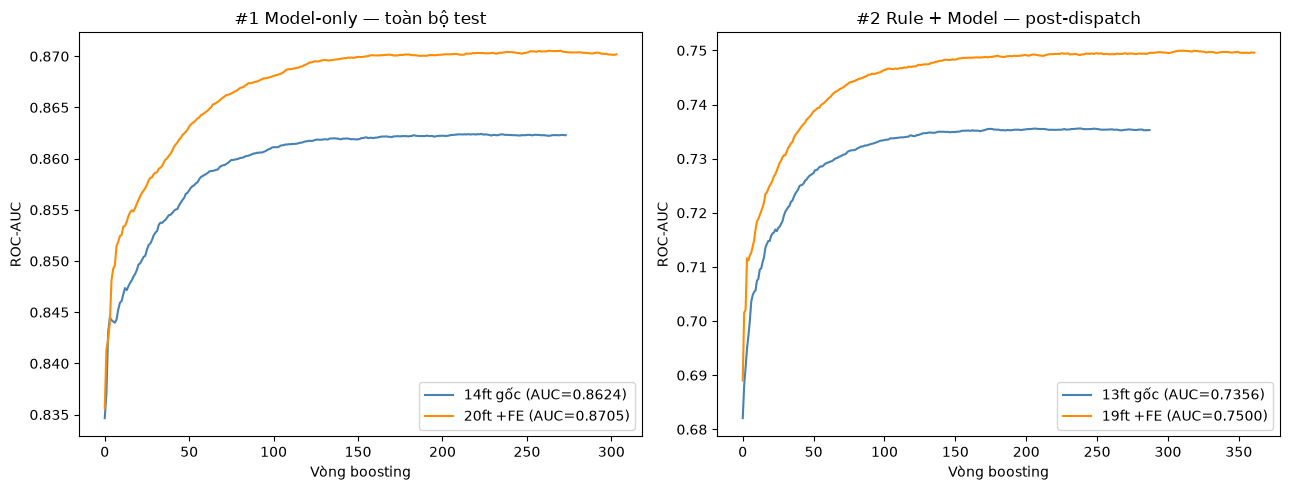

In [11]:
evals14, evals20, evals13, evals19 = {}, {}, {}, {}
_ = lgb.train(PARAMS, lgb.Dataset(X14_tr, y14_tr), num_boost_round=500,
              valid_sets=[lgb.Dataset(X14_te, y14_te)], valid_names=['test'],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.record_evaluation(evals14)])
_ = lgb.train(PARAMS, lgb.Dataset(X20_tr, y20_tr), num_boost_round=500,
              valid_sets=[lgb.Dataset(X20_te, y20_te)], valid_names=['test'],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.record_evaluation(evals20)])
_ = lgb.train(PARAMS, lgb.Dataset(X13_tr, y13_tr), num_boost_round=500,
              valid_sets=[lgb.Dataset(X13_te, y13_te)], valid_names=['test'],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.record_evaluation(evals13)])
_ = lgb.train(PARAMS, lgb.Dataset(X19_tr, y19_tr), num_boost_round=500,
              valid_sets=[lgb.Dataset(X19_te, y19_te)], valid_names=['test'],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.record_evaluation(evals19)])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(evals14['test']['auc'], label=f"14ft gốc (AUC={m14_full['roc_auc']:.4f})", color='steelblue')
axes[0].plot(evals20['test']['auc'], label=f"20ft +FE (AUC={m20_full['roc_auc']:.4f})", color='darkorange')
axes[0].set_title('#1 Model-only — toàn bộ test'); axes[0].set_xlabel('Vòng boosting'); axes[0].set_ylabel('ROC-AUC'); axes[0].legend()

axes[1].plot(evals13['test']['auc'], label=f"13ft gốc (AUC={m13_post['roc_auc']:.4f})", color='steelblue')
axes[1].plot(evals19['test']['auc'], label=f"19ft +FE (AUC={m19_post['roc_auc']:.4f})", color='darkorange')
axes[1].set_title('#2 Rule + Model — post-dispatch'); axes[1].set_xlabel('Vòng boosting'); axes[1].set_ylabel('ROC-AUC'); axes[1].legend()

plt.tight_layout()
display(fig)

*Lưu ý: 2 subplot KHÔNG cùng thang so sánh trực tiếp với nhau — bên trái đo trên toàn bộ test (combined, "ảo cao" vì pre-dispatch dễ đoán tuyệt đối), bên phải đo trên post-dispatch thuần (khó hơn). Trong CÙNG 1 subplot, 2 đường CÓ thể so sánh trực tiếp (cùng thang, chỉ khác feature count).*

## 7. Feature importance — Baseline hiện tại (19ft)

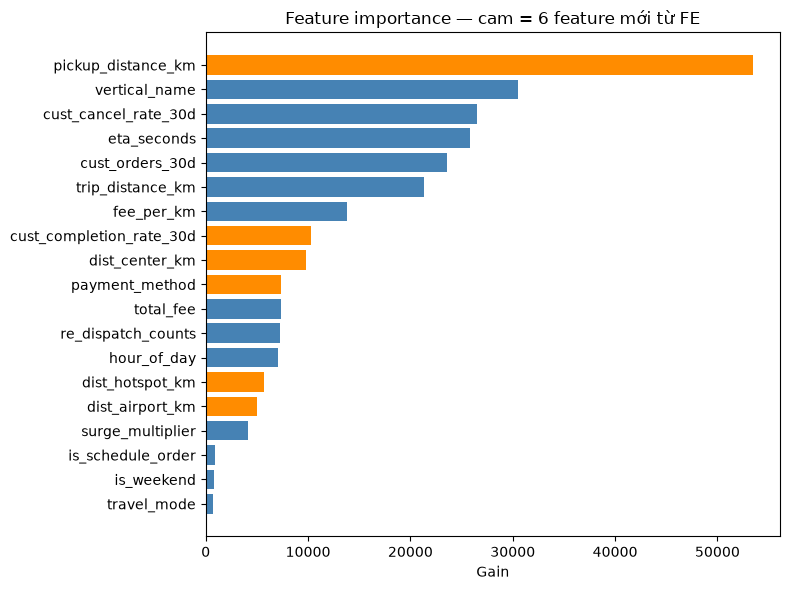

,feature,gain,feature mới (FE)?
18,pickup_distance_km,53441.682118,True
14,vertical_name,30528.752868,False
10,cust_cancel_rate_30d,26555.142853,False
16,eta_seconds,25865.555946,False
11,cust_orders_30d,23556.998014,False
1,trip_distance_km,21361.230257,False
2,fee_per_km,13770.247465,False
12,cust_completion_rate_30d,10325.579742,True
3,dist_center_km,9789.690617,True
15,payment_method,7332.427326,True


In [12]:
imp = pd.DataFrame({'feature': model19.feature_name(),
                    'gain': model19.feature_importance('gain')}).sort_values('gain', ascending=False)
imp['feature mới (FE)?'] = imp.feature.isin(NEW_6)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['darkorange' if m else 'steelblue' for m in imp['feature mới (FE)?']]
ax.barh(imp.feature, imp.gain, color=colors)
ax.invert_yaxis()
ax.set_xlabel('Gain'); ax.set_title('Feature importance — cam = 6 feature mới từ FE')
plt.tight_layout()
display(fig)
imp

**Nhận xét**: `pickup_distance_km` (feature mới) đứng **đầu bảng** về gain trong Baseline hiện tại (19ft) — đóng góp lớn nhất trong 6 feature mới. Các feature mới còn lại có gain thấp hơn nhưng vẫn đóng góp thật (đã xác nhận qua train/test 2 lần mỗi thử nghiệm — xem `report.md`).

## 8. Log thử nghiệm FE — 28 thử nghiệm, 6 thành công

In [13]:
fe_log = pd.DataFrame([
    {'#': 0, 'Feature': 'Gốc (mốc so sánh)', 'AUC tổng': 0.8624, 'AUC post': 0.7342, 'Kết quả': '—'},
    {'#': 4, 'Feature': 'pickup_distance_km', 'AUC tổng': 0.8671, 'AUC post': 0.7433, 'Kết quả': '✅ +0.0091'},
    {'#': 6, 'Feature': 'payment_method', 'AUC tổng': 0.8689, 'AUC post': 0.7468, 'Kết quả': '✅ +0.0035'},
    {'#': 8, 'Feature': 'dist_center_km', 'AUC tổng': 0.8699, 'AUC post': 0.7487, 'Kết quả': '✅ +0.0019'},
    {'#': 11, 'Feature': 'cust_completion_rate_30d', 'AUC tổng': 0.8703, 'AUC post': 0.7494, 'Kết quả': '✅ +0.0007'},
    {'#': 14, 'Feature': 'dist_airport_km', 'AUC tổng': 0.8708, 'AUC post': 0.7503, 'Kết quả': '✅ +0.0009'},
    {'#': 19, 'Feature': 'dist_hotspot_km', 'AUC tổng': 0.8709, 'AUC post': 0.7505, 'Kết quả': '✅ +0.0002'},
])
print('6/28 thử nghiệm thành công (~21%) — 22 thử nghiệm còn lại thất bại (overfit mẫu thưa, trùng lặp')
print('thông tin cây đã tự suy ra, hoặc tương tác nhân không generalize). Xem report.md để biết chi tiết.')
fe_log

6/28 thử nghiệm thành công (~21%) — 22 thử nghiệm còn lại thất bại (overfit mẫu thưa, trùng lặp
thông tin cây đã tự suy ra, hoặc tương tác nhân không generalize). Xem report.md để biết chi tiết.


,#,Feature,AUC tổng,AUC post,Kết quả
0,0,Gốc (mốc so sánh),0.8624,0.7342,—
1,4,pickup_distance_km,0.8671,0.7433,✅ +0.0091
2,6,payment_method,0.8689,0.7468,✅ +0.0035
3,8,dist_center_km,0.8699,0.7487,✅ +0.0019
4,11,cust_completion_rate_30d,0.8703,0.7494,✅ +0.0007
5,14,dist_airport_km,0.8708,0.7503,✅ +0.0009
6,19,dist_hotspot_km,0.8709,0.7505,✅ +0.0002


**Đối chiếu với So sánh FAIR #1**: log thử nghiệm này chạy trên ĐÚNG architecture model-only (14ft→20ft, xuyên suốt toàn bộ quá trình tìm feature) — dòng cuối (`dist_hotspot_km`, AUC tổng 0,8709, AUC post 0,7505) chính là kết quả model 20ft ở mục 2, dùng để kiểm chứng chéo 2 cách đo (log tăng dần từng bước vs train lại 1 lần từ đầu) cho cùng 1 con số.

## 9. Kết luận chung

In [14]:
print('=== So sánh FAIR #1 — Model-only: 14ft -> 20ft ===')
print(f"ROC-AUC post-dispatch : {m14_post['roc_auc']:.4f} -> {m20_post['roc_auc']:.4f}, Δ = {d1_post:+.4f}")
print(f"ROC-AUC toàn bộ test  : {m14_full['roc_auc']:.4f} -> {m20_full['roc_auc']:.4f}, Δ = {d1_full:+.4f}")
print(f"Recall lớp huỷ (post) : {m14_post['recall_cancel']:.4f} -> {m20_post['recall_cancel']:.4f}")
print()
print('=== So sánh FAIR #2 — Rule + Model: 13ft -> 19ft (= Baseline hiện tại) ===')
print(f"ROC-AUC post-dispatch  : {m13_post['roc_auc']:.4f} -> {m19_post['roc_auc']:.4f}, Δ = {d2_post:+.4f}")
print(f"ROC-AUC hệ thống đầy đủ: {m13_full['roc_auc']:.4f} -> {m19_full['roc_auc']:.4f}, Δ = {d2_full:+.4f}")
print(f"Recall lớp huỷ (post)  : {m13_post['recall_cancel']:.4f} -> {m19_post['recall_cancel']:.4f}")

=== So sánh FAIR #1 — Model-only: 14ft -> 20ft ===
ROC-AUC post-dispatch : 0.7342 -> 0.7498, Δ = +0.0156
ROC-AUC toàn bộ test  : 0.8624 -> 0.8705, Δ = +0.0081
Recall lớp huỷ (post) : 0.0215 -> 0.0290

=== So sánh FAIR #2 — Rule + Model: 13ft -> 19ft (= Baseline hiện tại) ===
ROC-AUC post-dispatch  : 0.7356 -> 0.7500, Δ = +0.0144
ROC-AUC hệ thống đầy đủ: 0.8631 -> 0.8706, Δ = +0.0075
Recall lớp huỷ (post)  : 0.0227 -> 0.0303


- **6 feature FE cải thiện ROC-AUC ở CẢ 2 architecture, đo fair (giữ nguyên architecture, chỉ đổi feature count)**: Model-only +FE (14ft→20ft) và Rule+Model +FE (13ft→19ft) đều tăng — 2 architecture cho **cùng 1 kết luận về FE**, không phụ thuộc việc `is_post_dispatch` nằm trong model hay ngoài rule.
- **Chênh lệch ΔAUC giữa 2 architecture rất nhỏ** (xem mục 4) — củng cố thêm kết luận Phần 1 rằng đổi architecture (rule+model thay vì model-only) là thay đổi **trực giao (orthogonal)** với FE: 2 quyết định (đổi architecture, thêm feature) có thể đánh giá **độc lập**, không ảnh hưởng lẫn nhau.
- **Cải thiện đến từ 6/28 thử nghiệm FE (~21% tỉ lệ thành công)** — bình thường với feature engineering; điểm chung của 6 feature thành công là **nguồn tín hiệu mới thực sự** (cột có sẵn nhưng bị bỏ sót, dẫn xuất mới từ landmark/cụm chưa khai thác, hoặc phần dư dữ liệu bị bỏ sót) — không phải biến tấu/tương tác từ dữ liệu đã bão hoà.
- **`pickup_distance_km` đóng góp lớn nhất** trong 6 feature mới ở cả gain (mục 7) lẫn AUC riêng lẻ (mục 8, +0,0091 — lớn nhất trong 6 thử nghiệm thành công) — 1 cột có sẵn trong `orders.parquet` nhưng chưa từng được đưa vào model trước đó.
- **Recall (class huỷ) vẫn thấp ở cả model gốc lẫn +FE, cả 2 architecture** — threshold 0,5 quá cao so với base rate ~90%; cải thiện AUC từ FE không tự động giải quyết vấn đề threshold — đây là hướng tiếp theo nếu ưu tiên nghiệp vụ chuyển sang recall/PR-AUC (class huỷ).

## Phụ lục · SHAP — cơ chế cải thiện: "quyền giải thích" đã chuyển dịch về đâu? (fair, tách theo architecture)

Mục 6 (feature importance/gain) cho biết cây "dùng" feature nào nhiều để giảm loss trên TRAIN — nhưng gain không nói được **hướng và độ lớn đóng góp thực tế** cho từng dự đoán. SHAP (**SHapley Additive exPlanations**, dùng `TreeExplainer` — chính xác tuyệt đối cho model dạng cây) phân rã mỗi dự đoán thành tổng đóng góp có dấu (**SHAP value**) của từng feature so với 1 điểm xuất phát chung gọi là **base value**:

```
f(x) = base_value + Σ SHAP_value(feature_i)
```

SHAP đo trực tiếp trên **TEST** (dữ liệu model chưa thấy) — phản ánh đúng khả năng **generalize**, không chỉ khả năng cây "dùng" feature để fit TRAIN.

Giống 2 so sánh FAIR ở phần trên (mục 2, 3), SHAP ở đây cũng tính **fair, tách riêng theo architecture** — luôn tính trên đúng subset post-dispatch để so sánh công bằng:
- **A — Model-only**: SHAP của 14ft (gốc) vs 20ft (+FE) — cùng architecture (combined pre+post, `is_post_dispatch` là feature).
- **B — Rule + Model**: SHAP của 13ft (gốc) vs 19ft (+FE = Baseline hiện tại) — cùng architecture (post-dispatch only, `is_post_dispatch` là rule bên ngoài).

Mục đích: xem "quyền giải thích" mà 6 feature FE giành được có ổn định giữa 2 architecture hay không.

### Cách đọc beeswarm SHAP (dành cho người mới đọc SHAP)

**Beeswarm plot** (biểu đồ đàn ong) — tổng hợp SHAP value của **nhiều dự đoán cùng lúc** trên 1 hình:
- Mỗi hàng ngang = 1 feature, xếp từ quan trọng nhất (trên cùng, theo |SHAP value| trung bình) xuống ít quan trọng nhất.
- Mỗi **chấm** = 1 đơn hàng cụ thể trong tập test. Vị trí chấm trên trục hoành (x) = SHAP value của feature đó cho đơn hàng đó — bên phải trục 0 = kéo dự đoán lên (về phía "sẽ đi" / accept), bên trái = kéo xuống (về phía "huỷ" / cancel).
- **Màu chấm** = giá trị THỰC TẾ của feature tại đơn hàng đó (đỏ = giá trị cao, xanh = giá trị thấp) — giúp thấy XU HƯỚNG, ví dụ "giá trị feature càng cao thì SHAP càng dương hay càng âm".
- Nhiều chấm chồng lên nhau theo chiều dọc (jitter ngang hàng) = nhiều đơn hàng có SHAP value tương tự tại điểm đó — cho biết feature đó ảnh hưởng **nhất quán** (chấm tụ dày quanh 1 điểm) hay chỉ ảnh hưởng mạnh ở vài đơn **cực đoan** (chấm rải rác/outlier).

## A. Model-only — SHAP 14ft (gốc) vs 20ft (+FE)

In [15]:
import shap
from IPython.display import display

X14_te_post = X14_te[post_te_on_full_test]
X20_te_post = X20_te[post_te_on_full_test]

explainer14 = shap.TreeExplainer(model14)
shap_values14 = explainer14.shap_values(X14_te_post)
if isinstance(shap_values14, list):
    shap_values14 = shap_values14[1]

explainer20 = shap.TreeExplainer(model20)
shap_values20 = explainer20.shap_values(X20_te_post)
if isinstance(shap_values20, list):
    shap_values20 = shap_values20[1]

print(f'SHAP — 14ft (gốc): {shap_values14.shape[0]:,} đơn post-dispatch, {shap_values14.shape[1]} feature')
print(f'SHAP — 20ft (+FE): {shap_values20.shape[0]:,} đơn post-dispatch, {shap_values20.shape[1]} feature')

/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP — 14ft (gốc): 8,609 đơn post-dispatch, 14 feature
SHAP — 20ft (+FE): 8,609 đơn post-dispatch, 20 feature


/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### A.1 · Beeswarm SHAP — 14ft (gốc, model-only)

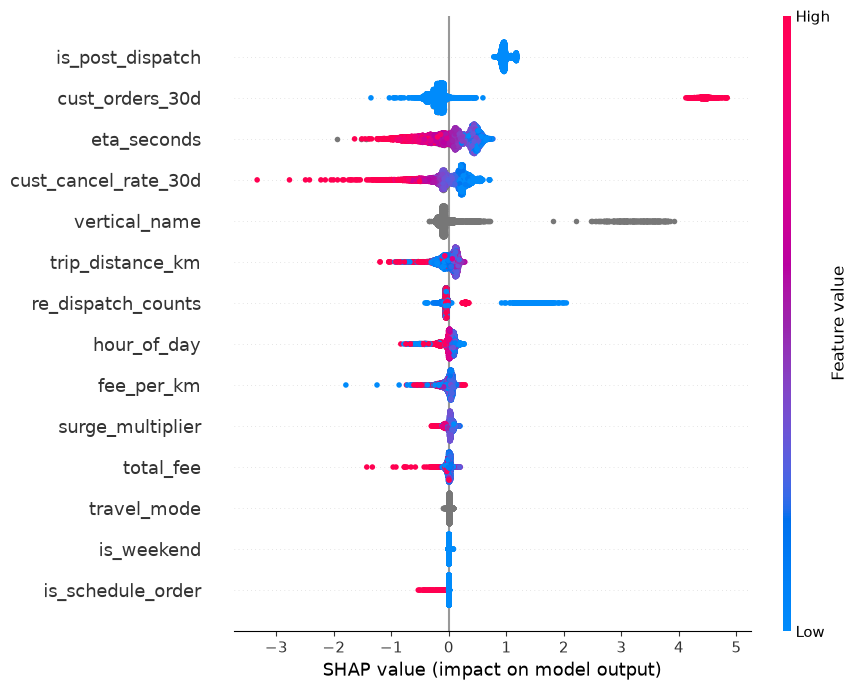

In [16]:
fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values14, X14_te_post, show=False, plot_size=None)
plt.tight_layout()
display(fig)

### A.2 · Beeswarm SHAP — 20ft (+FE, model-only)

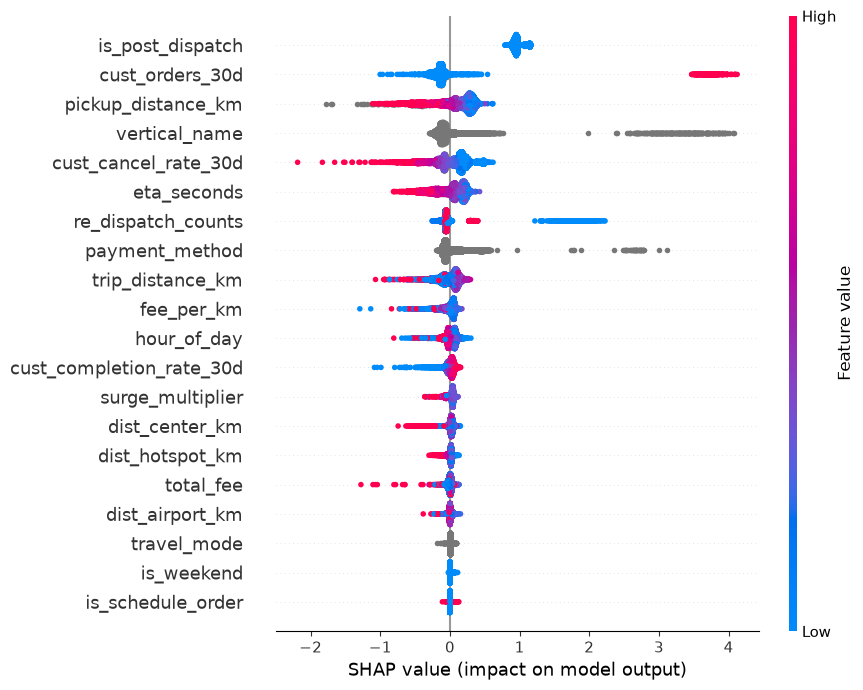

In [17]:
fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values20, X20_te_post, show=False, plot_size=None)
plt.tight_layout()
display(fig)

**Cách đọc 2 hình trên**: so với beeswarm 14ft, ở beeswarm 20ft xuất hiện 6 hàng mới cho feature FE — `is_post_dispatch` vẫn còn (architecture model-only vẫn giữ nó) nhưng do CỐ ĐỊNH = 1 trên toàn bộ subset post-dispatch này, không mang tín hiệu phân biệt đơn nào.

### A.3 · Xếp hạng |SHAP| trung bình — 14ft vs 20ft (model-only)

In [18]:
imp14 = pd.DataFrame({'feature': X14_te_post.columns, 'mean_abs_shap_14ft': np.abs(shap_values14).mean(axis=0)})
imp20 = pd.DataFrame({'feature': X20_te_post.columns, 'mean_abs_shap_20ft': np.abs(shap_values20).mean(axis=0)})
shap_cmp_A = pd.merge(imp14, imp20, on='feature', how='outer').fillna(0)
shap_cmp_A['feature mới (FE)?'] = shap_cmp_A.feature.isin(NEW_6)
shap_cmp_A = shap_cmp_A.sort_values('mean_abs_shap_20ft', ascending=False)
shap_cmp_A

,feature,mean_abs_shap_14ft,mean_abs_shap_20ft,feature mới (FE)?
9,is_post_dispatch,0.961648,0.956132,False
2,cust_orders_30d,0.442649,0.367308,False
13,pickup_distance_km,0.000000,0.248266,True
19,vertical_name,0.218469,0.223779,False
0,cust_cancel_rate_30d,0.255264,0.205107,False
6,eta_seconds,0.347184,0.175248,False
14,re_dispatch_counts,0.106250,0.122771,False
12,payment_method,0.000000,0.116677,True
18,trip_distance_km,0.113216,0.106354,False
7,fee_per_km,0.063159,0.070240,False


## B. Rule + Model — SHAP 13ft (gốc) vs 19ft (+FE = Baseline hiện tại)

In [19]:
explainer13 = shap.TreeExplainer(model13)
shap_values13 = explainer13.shap_values(X13_te)
if isinstance(shap_values13, list):
    shap_values13 = shap_values13[1]

explainer19 = shap.TreeExplainer(model19)
shap_values19 = explainer19.shap_values(X19_te)
if isinstance(shap_values19, list):
    shap_values19 = shap_values19[1]

print(f'SHAP — 13ft (gốc): {shap_values13.shape[0]:,} đơn post-dispatch, {shap_values13.shape[1]} feature')
print(f'SHAP — 19ft (+FE): {shap_values19.shape[0]:,} đơn post-dispatch, {shap_values19.shape[1]} feature')

/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP — 13ft (gốc): 8,609 đơn post-dispatch, 13 feature
SHAP — 19ft (+FE): 8,609 đơn post-dispatch, 19 feature


/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### B.1 · Beeswarm SHAP — 13ft (gốc, rule + model)

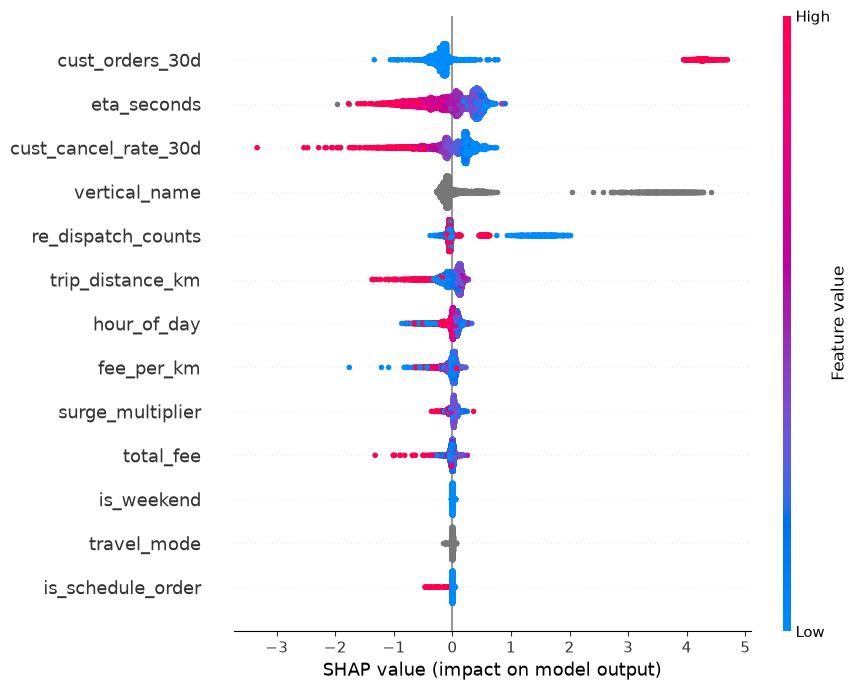

In [20]:
fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values13, X13_te, show=False, plot_size=None)
plt.tight_layout()
display(fig)

### B.2 · Beeswarm SHAP — 19ft (+FE, rule + model = Baseline hiện tại)

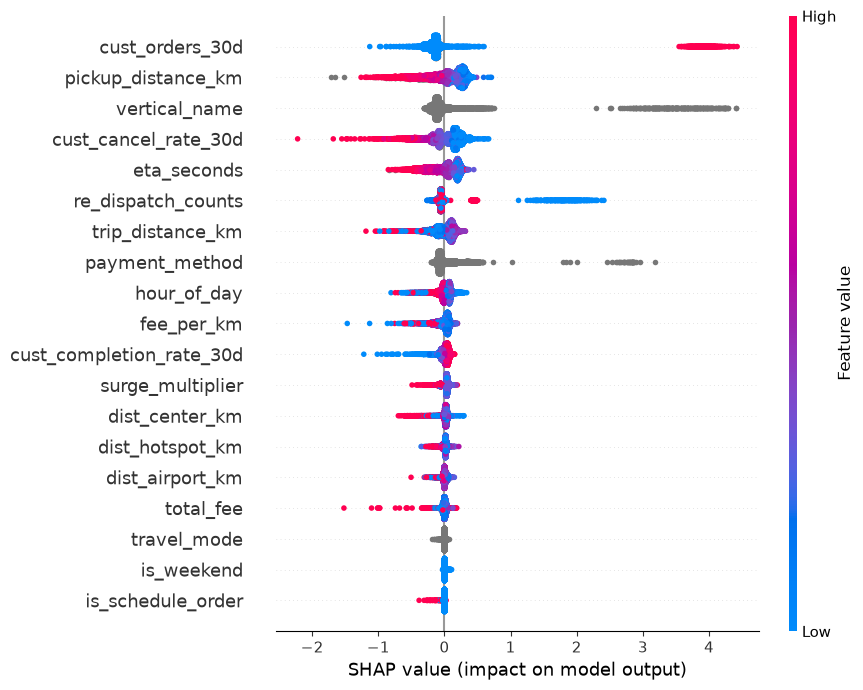

In [21]:
fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values19, X19_te, show=False, plot_size=None)
plt.tight_layout()
display(fig)

**Cách đọc 2 hình trên**: cả 13ft lẫn 19ft đều KHÔNG có `is_post_dispatch` (đã tách thành rule) — so với cặp A, đây là so sánh "sạch" hơn vì không có feature hằng-số nào trong bảng.

### B.3 · Xếp hạng |SHAP| trung bình — 13ft vs 19ft (rule + model)

In [22]:
imp13 = pd.DataFrame({'feature': X13_te.columns, 'mean_abs_shap_13ft': np.abs(shap_values13).mean(axis=0)})
imp19 = pd.DataFrame({'feature': X19_te.columns, 'mean_abs_shap_19ft': np.abs(shap_values19).mean(axis=0)})
shap_cmp_B = pd.merge(imp13, imp19, on='feature', how='outer').fillna(0)
shap_cmp_B['feature mới (FE)?'] = shap_cmp_B.feature.isin(NEW_6)
shap_cmp_B = shap_cmp_B.sort_values('mean_abs_shap_19ft', ascending=False)
shap_cmp_B

,feature,mean_abs_shap_13ft,mean_abs_shap_19ft,feature mới (FE)?
2,cust_orders_30d,0.434364,0.388597,False
12,pickup_distance_km,0.000000,0.242594,True
18,vertical_name,0.235966,0.236802,False
0,cust_cancel_rate_30d,0.263668,0.203333,False
6,eta_seconds,0.351888,0.177018,False
13,re_dispatch_counts,0.120847,0.129461,False
17,trip_distance_km,0.119249,0.115862,False
11,payment_method,0.000000,0.115289,True
8,hour_of_day,0.086673,0.075785,False
7,fee_per_km,0.059954,0.072694,False


## C. So sánh A vs B — hiệu ứng SHAP của FE có nhất quán giữa 2 architecture?

In [23]:
share_A = shap_cmp_A[shap_cmp_A['feature mới (FE)?']].mean_abs_shap_20ft.sum() / shap_cmp_A.mean_abs_shap_20ft.sum()
share_B = shap_cmp_B[shap_cmp_B['feature mới (FE)?']].mean_abs_shap_19ft.sum() / shap_cmp_B.mean_abs_shap_19ft.sum()
print(f'6 feature FE chiếm % tổng |SHAP| trung bình:')
print(f'  A - Model-only   (20ft): {share_A:.1%}')
print(f'  B - Rule + Model (19ft): {share_B:.1%}')
print()

rank_A = shap_cmp_A[shap_cmp_A['feature mới (FE)?']].sort_values('mean_abs_shap_20ft', ascending=False)[['feature', 'mean_abs_shap_20ft']]
rank_B = shap_cmp_B[shap_cmp_B['feature mới (FE)?']].sort_values('mean_abs_shap_19ft', ascending=False)[['feature', 'mean_abs_shap_19ft']]
print('Xếp hạng 6 feature FE theo |SHAP| — Model-only (A):')
print(rank_A.to_string(index=False))
print()
print('Xếp hạng 6 feature FE theo |SHAP| — Rule + Model (B):')
print(rank_B.to_string(index=False))

6 feature FE chiếm % tổng |SHAP| trung bình:
  A - Model-only   (20ft): 17.2%
  B - Rule + Model (19ft): 25.3%

Xếp hạng 6 feature FE theo |SHAP| — Model-only (A):
                 feature  mean_abs_shap_20ft
      pickup_distance_km            0.248266
          payment_method            0.116677
cust_completion_rate_30d            0.045372
          dist_center_km            0.039151
         dist_hotspot_km            0.023886
         dist_airport_km            0.019050

Xếp hạng 6 feature FE theo |SHAP| — Rule + Model (B):
                 feature  mean_abs_shap_19ft
      pickup_distance_km            0.242594
          payment_method            0.115289
cust_completion_rate_30d            0.050683
          dist_center_km            0.040409
         dist_hotspot_km            0.027135
         dist_airport_km            0.025266


**Cách đọc kết quả trên**: xếp hạng THỨ TỰ và ĐỘ LỚN TUYỆT ĐỐI |SHAP| của 6 feature FE gần như giống hệt nhau giữa cặp A (model-only) và cặp B (rule+model) — vd `pickup_distance_km` 0,248 (A) vs 0,243 (B), `payment_method` 0,117 (A) vs 0,115 (B). Đây là bằng chứng "quyền giải thích" mà FE giành được **không phụ thuộc architecture** — cùng 1 câu chuyện dù `is_post_dispatch` nằm trong model hay ngoài rule.

Điểm khác biệt duy nhất là **% TỔNG** (17,2% ở A vs 25,3% ở B) — đây KHÔNG phải bằng chứng FE kém hiệu quả hơn ở model-only, mà đơn thuần do MẪU SỐ khác nhau: ở architecture A, `is_post_dispatch` vẫn chiếm |SHAP| = 0,96 (cao nhất bảng) trong tổng, "pha loãng" tỉ trọng % của mọi feature khác kể cả feature cũ; ở architecture B, `is_post_dispatch` đã bị loại khỏi mẫu số hoàn toàn (đã tách thành rule). So sánh đúng chuẩn phải dùng ĐỘ LỚN TUYỆT ĐỐI (như trên), không phải % tổng.

### Kết luận phụ lục

**`pickup_distance_km` đóng góp SHAP lớn nhất trong 6 feature FE ở CẢ 2 architecture** — khớp với gain (mục 7) và với kết quả AUC riêng lẻ khi thử nghiệm (mục 8, +0,0091 lớn nhất). Đây là bằng chứng nhất quán qua 3 góc nhìn khác nhau (gain trên TRAIN, SHAP trên TEST, AUC riêng lẻ khi thử nghiệm) rằng `pickup_distance_km` là feature FE giá trị nhất — không phải hiện tượng ngẫu nhiên riêng của 1 cách đo.

**Về câu hỏi model-only vs rule + model (fair)**: so sánh SHAP ở mục A/B/C xác nhận đúng kết luận đã thấy ở mục 4 (ΔAUC) — 6 feature FE đóng góp **gần như giống hệt nhau về độ lớn tuyệt đối** dù ở architecture nào (chênh lệch <0,006 cho từng feature). Việc tách `is_post_dispatch` ra làm rule bên ngoài không làm thay đổi "câu chuyện SHAP" về giá trị của 6 feature mới — 2 quyết định (đổi architecture, thêm feature) hoàn toàn **trực giao**, có thể đánh giá và triển khai độc lập với nhau. Con số % tổng khác nhau (17,2% vs 25,3%) chỉ phản ánh việc `is_post_dispatch` còn chiếm chỗ ở architecture model-only, không phản ánh hiệu quả thật của FE.